# Regression Model

## Steps:

### Data Preparation

* Data loading
* Data preparation
* Creating sequences
* Creating datasets  
* Creating dataloaders

### Model
* Model definition
* Loss function
* Optimizer

### Training
* Train loop
* Validation loop

### Evaluation
* Metrics
* Plots

## Data Preparation

Importing libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
import os

Connecting to google drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Loading data

In [4]:
general_path = '/content/drive/My Drive/RS - IEEE - ESA/notebooks'  # ajusta la ruta
list_of_files = os.listdir(general_path)
list_of_parquet = [f for f in list_of_files if '.parquet' in f]
print(list_of_parquet)

dataframes = {}

for file in list_of_parquet:
  file_path = os.path.join(general_path, file)
  print(file)

  # if "precipitation" in file:
  #   continue

  df = pd.read_parquet(file_path)
  df_resampled = df.copy()

  print(df.info())

  if 'discharge' in str(file):
    df_resampled = df.resample('30min').mean()
  else:
    df_resampled = df.resample('30min').sum()

  file_prefix = file.replace('.parquet', '')
  df_resampled.columns = [f"{file_prefix}" for col in df_resampled.columns]

  # Store in dictionary
  dataframes[file] = df_resampled

# Merge using outer join to keep all timestamps
merged_df = pd.concat(dataframes.values(), axis=1, join='outer')

# Sort by index
merged_df = merged_df.sort_index()


['discharge_laa.parquet', 'discharge_klu.parquet', 'precipitation_bar.parquet', 'precipitation_sch.parquet']
discharge_laa.parquet
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 854313 entries, 2016-11-30 23:00:00+00:00 to 2025-12-31 22:55:00+00:00
Data columns (total 1 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Abfluss (m³/s)  854313 non-null  float64
dtypes: float64(1)
memory usage: 13.0 MB
None
discharge_klu.parquet
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1375033 entries, 2009-12-31 23:00:00+00:00 to 2025-12-31 22:59:30+00:00
Data columns (total 1 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Abfluss (m³/s)  1375033 non-null  float64
dtypes: float64(1)
memory usage: 21.0 MB
None
precipitation_bar.parquet
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 96007 entries, 2019-04-19 23:15:00+00:00 to 2022-01-20 11:00:00+00:00
Data columns (

In [5]:
dataframes.keys()

dict_keys(['discharge_laa.parquet', 'discharge_klu.parquet', 'precipitation_bar.parquet', 'precipitation_sch.parquet'])

In [6]:
merged_df

,discharge_laa,discharge_klu,precipitation_bar,precipitation_sch
Phenomenon,,,,
2009-12-31 23:00:00+00:00,NaN,30.813333,NaN,NaN
2009-12-31 23:30:00+00:00,NaN,30.615000,NaN,NaN
2010-01-01 00:00:00+00:00,NaN,30.540000,NaN,NaN
2010-01-01 00:30:00+00:00,NaN,30.440000,NaN,NaN
2010-01-01 01:00:00+00:00,NaN,30.415000,NaN,NaN
...,...,...,...,...
2025-12-31 20:30:00+00:00,3.786667,3.706667,NaN,NaN
2025-12-31 21:00:00+00:00,3.896000,3.706667,NaN,NaN
2025-12-31 21:30:00+00:00,3.994000,3.643333,NaN,NaN


In [7]:
merged_df.dropna(inplace=True)

In [8]:
merged_df

,discharge_laa,discharge_klu,precipitation_bar,precipitation_sch
Phenomenon,,,,
2019-04-19 23:00:00+00:00,2.213333,3.493333,0.0,0.0
2019-04-19 23:30:00+00:00,2.253333,3.480000,0.0,0.0
2019-04-20 00:00:00+00:00,2.193333,3.490000,0.0,0.0
2019-04-20 00:30:00+00:00,2.208333,3.480000,0.0,0.0
2019-04-20 01:00:00+00:00,2.215000,3.480000,0.0,0.0
...,...,...,...,...
2022-01-20 09:00:00+00:00,4.106667,6.830000,0.0,0.0
2022-01-20 09:30:00+00:00,4.228333,6.825000,0.0,0.0
2022-01-20 10:00:00+00:00,4.658333,6.768333,0.0,0.0


In [9]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43708 entries, 2019-04-19 23:00:00+00:00 to 2022-01-20 11:00:00+00:00
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   discharge_laa      43708 non-null  float64
 1   discharge_klu      43708 non-null  float64
 2   precipitation_bar  43708 non-null  float64
 3   precipitation_sch  43708 non-null  float64
dtypes: float64(4)
memory usage: 1.7 MB


In [10]:
merged_df.corr(method='spearman')

,discharge_laa,discharge_klu,precipitation_bar,precipitation_sch
discharge_laa,1.000000,0.864249,0.077808,0.082884
discharge_klu,0.864249,1.000000,0.132274,0.136534
precipitation_bar,0.077808,0.132274,1.000000,0.657000
precipitation_sch,0.082884,0.136534,0.657000,1.000000


In [11]:
merged_df.describe()

,discharge_laa,discharge_klu,precipitation_bar,precipitation_sch
count,43708.000000,43708.000000,43708.000000,43708.000000
mean,4.965650,7.077759,0.040725,0.038460
std,5.475072,7.597540,0.321281,0.306366
min,0.052500,0.020000,0.000000,0.000000
25%,2.555000,3.513767,0.000000,0.000000
50%,2.926667,4.295000,0.000000,0.000000
75%,4.696167,6.663690,0.000000,0.000000
max,55.370000,180.724590,15.000000,12.000000


In [12]:
# Save dataset
dataset_name = "dataset.parquet"
general_path_parquet = '/content/drive/My Drive/RS - IEEE - ESA/notebooks'  # ajusta la ruta
os.makedirs(os.path.join(general_path_parquet, 'datasets'), exist_ok=True)
dataset_path = os.path.join(general_path_parquet, 'datasets', dataset_name)
merged_df.to_parquet(dataset_path)

In [13]:
data = pd.read_parquet(dataset_path)

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43708 entries, 2019-04-19 23:00:00+00:00 to 2022-01-20 11:00:00+00:00
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   discharge_laa      43708 non-null  float64
 1   discharge_klu      43708 non-null  float64
 2   precipitation_bar  43708 non-null  float64
 3   precipitation_sch  43708 non-null  float64
dtypes: float64(4)
memory usage: 1.7 MB


splitting data into train, validation and test

In [15]:
def train_val_test_split_by_date(data, train_end_date, val_end_date):
    """
    Split time series by specific dates.

    Parameters:
    -----------
    data : pandas DataFrame with DatetimeIndex
    train_end_date : str or datetime
        Last date for training set
    val_end_date : str or datetime
        Last date for validation set

    Returns:
    --------
    train, val, test : pandas DataFrame
    """
    train = data[:train_end_date]
    val = data[train_end_date:val_end_date]
    test = data[val_end_date:]

    return train, val, test

clasificación

data = temp, test --> 70% / 30%
temp = train, valid --> 70% / 30%
(aleatorio, si no hay dependencia temporal)



In [16]:
train, val, test = train_val_test_split_by_date(
    data,
    train_end_date='2021-01-01',
    val_end_date='2021-07-01')

In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 27518 entries, 2019-04-19 23:00:00+00:00 to 2021-01-01 23:30:00+00:00
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   discharge_laa      27518 non-null  float64
 1   discharge_klu      27518 non-null  float64
 2   precipitation_bar  27518 non-null  float64
 3   precipitation_sch  27518 non-null  float64
dtypes: float64(4)
memory usage: 1.0 MB


In [18]:
val.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6826 entries, 2021-01-01 00:00:00+00:00 to 2021-07-01 23:30:00+00:00
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   discharge_laa      6826 non-null   float64
 1   discharge_klu      6826 non-null   float64
 2   precipitation_bar  6826 non-null   float64
 3   precipitation_sch  6826 non-null   float64
dtypes: float64(4)
memory usage: 266.6 KB


In [19]:
train.head(5)

,discharge_laa,discharge_klu,precipitation_bar,precipitation_sch
Phenomenon,,,,
2019-04-19 23:00:00+00:00,2.213333,3.493333,0.0,0.0
2019-04-19 23:30:00+00:00,2.253333,3.480000,0.0,0.0
2019-04-20 00:00:00+00:00,2.193333,3.490000,0.0,0.0
2019-04-20 00:30:00+00:00,2.208333,3.480000,0.0,0.0
2019-04-20 01:00:00+00:00,2.215000,3.480000,0.0,0.0


In [20]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler


def scale(train, val, test, method='minmax'):
    """
    Scale data using only training set statistics.

    Parameters:
    -----------
    train, val, test : pandas DataFrame
    method : str
        'minmax' or 'standard'

    Returns:
    --------
    train_scaled, val_scaled, test_scaled, scaler
    """
    # Choose scaler
    if method == 'minmax':
        scaler = MinMaxScaler()
    elif method == 'standard':
        scaler = StandardScaler()
    else:
        raise ValueError("method must be 'minmax' or 'standard'")

    # Fit on train, transform all (keeping DataFrame structure)
    train_scaled = pd.DataFrame(
        scaler.fit_transform(train),
        index=train.index,
        columns=train.columns
    )

    val_scaled = pd.DataFrame(
        scaler.transform(val),
        index=val.index,
        columns=val.columns
    )

    test_scaled = pd.DataFrame(
        scaler.transform(test),
        index=test.index,
        columns=test.columns
    )

    return train_scaled, val_scaled, test_scaled, scaler


def inverse_scale(data, scaler):
    """
    Inverse transform scaled data back to original scale.

    Parameters:
    -----------
    data : numpy array or pandas DataFrame
        Scaled data
    scaler : sklearn scaler object
        Fitted scaler from scale_train_only()

    Returns:
    --------
    numpy array or pandas DataFrame in original scale
    """
    return scaler.inverse_transform(data)

In [21]:
train_scaled, val_scaled, test_scaled, scaler_train = scale(train, val, test, method='standard')

Splitting data into X (input data) and y (target)

In [22]:
def split_features_target(data, target_column):
    """
    Split DataFrame into features (X) and target (y).

    Parameters:
    -----------
    data : pandas DataFrame
        The dataset to split
    target_column : str or list of str
        Name(s) of the target column(s)

    Returns:
    --------
    X : pandas DataFrame
        Features (all columns except target)
    y : pandas DataFrame or Series
        Target column(s)
    """
    if isinstance(target_column, str):
        # Single target column
        y = data[[target_column]]  # Keep as DataFrame
        X = data.drop(columns=[target_column])
    else:
        # Multiple target columns
        y = data[target_column]
        X = data.drop(columns=target_column)

    return X, y

In [23]:
target_column='discharge_klu'
X_train, y_train = split_features_target(train_scaled, target_column)
X_val, y_val = split_features_target(val_scaled, target_column)
X_test, y_test = split_features_target(test_scaled, target_column)

In [24]:
X_train

,discharge_laa,precipitation_bar,precipitation_sch
Phenomenon,,,
2019-04-19 23:00:00+00:00,-0.413554,-0.130737,-0.123956
2019-04-19 23:30:00+00:00,-0.405895,-0.130737,-0.123956
2019-04-20 00:00:00+00:00,-0.417383,-0.130737,-0.123956
2019-04-20 00:30:00+00:00,-0.414511,-0.130737,-0.123956
2019-04-20 01:00:00+00:00,-0.413235,-0.130737,-0.123956
...,...,...,...
2021-01-01 21:00:00+00:00,-0.032854,-0.130737,-0.123956
2021-01-01 22:00:00+00:00,-0.027429,-0.130737,-0.123956
2021-01-01 22:30:00+00:00,-0.054234,-0.130737,-0.123956


In [25]:
y_train

,discharge_klu
Phenomenon,
2019-04-19 23:00:00+00:00,-0.397514
2019-04-19 23:30:00+00:00,-0.399381
2019-04-20 00:00:00+00:00,-0.397981
2019-04-20 00:30:00+00:00,-0.399381
2019-04-20 01:00:00+00:00,-0.399381
...,...
2021-01-01 21:00:00+00:00,-0.137987
2021-01-01 22:00:00+00:00,-0.141722
2021-01-01 22:30:00+00:00,-0.139855


Creating sequences:
Input: lookback (how many time stamps the model has to learn from the past)
Target: horizon (how many time stamps the model will forecast into the future)

In [26]:
import numpy as np


def create_sequences(X_data, y_data, lookback, horizon):
    """
    Create sequences for multivariate multi-step time series forecasting.

    Parameters:
    -----------
    X_data : numpy array or pandas DataFrame
        Feature data (all input variables)
    y_data : numpy array or pandas DataFrame
        Target data (variable(s) to predict)
    lookback : int
        Number of past time steps to use as input (window size)
    horizon : int
        Number of future time steps to predict

    Returns:
    --------
    X : numpy array, shape (samples, lookback, n_features)
        Input sequences (past features)
    y : numpy array, shape (samples, horizon, n_targets)
        Target sequences (future target values)
    """
    X, y = [], []

    # Convert to numpy if DataFrame
    if hasattr(X_data, 'values'):
        X_data = X_data.values
    if hasattr(y_data, 'values'):
        y_data = y_data.values

    for i in range(len(X_data) - lookback - horizon + 1):
        # Input: past 'lookback' time steps of features
        X.append(X_data[i:i + lookback])

        # Output: next 'horizon' time steps of target
        y.append(y_data[i + lookback:i + lookback + horizon])

    X = np.array(X)
    y = np.array(y)

    return X, y

In [27]:
import os
lookback = 12 # 12 Timestamps --> Each timestamp 15 min --> 3 hours into the past
horizon = 8 # 8 Timestamps --> 2 hours into the future

# create sequences
X_train_seq, y_train_seq = create_sequences(X_train, y_train, lookback, horizon)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, lookback, horizon)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, lookback, horizon)


In [28]:
print("First sequence of X_train:")
print(X_train_seq[0])
print(f"\nShape: {X_train_seq[0].shape}")

First sequence of X_train:
[[-0.41355397 -0.13073671 -0.12395607]
 [-0.40589529 -0.13073671 -0.12395607]
 [-0.41738331 -0.13073671 -0.12395607]
 [-0.41451131 -0.13073671 -0.12395607]
 [-0.41323486 -0.13073671 -0.12395607]
 [-0.47201525 -0.13073671 -0.12395607]
 [-0.4116393  -0.13073671 -0.12395607]
 [-0.41004374 -0.13073671 -0.12395607]
 [-0.40780996 -0.13073671 -0.12395607]
 [-0.53194444 -0.13073671 -0.12395607]
 [-0.52843421 -0.13073671 -0.12395607]
 [-0.55141026 -0.13073671 -0.12395607]]

Shape: (12, 3)


In [29]:
print("First sequence of y_train:")
print(y_train_seq[0])
print(f"\nShape: {y_train_seq[0].shape}")

First sequence of y_train:
[[-0.40498234]
 [-0.40498234]
 [-0.40498234]
 [-0.40498234]
 [-0.40218169]
 [-0.40218169]
 [-0.40498234]
 [-0.40498234]]

Shape: (8, 1)


In [30]:
import joblib

def save_sequences(X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, scaler_train, save_dir):
    # Save sequences
    np.save(os.path.join(save_dir, "X_train_seq.npy"), X_train_seq)
    np.save(os.path.join(save_dir, "y_train_seq.npy"), y_train_seq)
    np.save(os.path.join(save_dir, "X_val_seq.npy"), X_val_seq)
    np.save(os.path.join(save_dir, "y_val_seq.npy"), y_val_seq)
    np.save(os.path.join(save_dir, "X_test_seq.npy"), X_test_seq)
    np.save(os.path.join(save_dir, "y_test_seq.npy"), y_test_seq)

    # Save scalers
    joblib.dump(scaler_train, os.path.join(save_dir, "scaler_train.pkl"))
    #joblib.dump(scaler_y, os.path.join(save_dir, "scaler_y.pkl"))



In [31]:
# Save sequences
save_dir = os.path.join(general_path_parquet, 'sequences')
os.makedirs(save_dir, exist_ok=True)
print(save_dir)

save_sequences(X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, scaler_train, save_dir)


/content/drive/My Drive/RS - IEEE - ESA/notebooks/sequences


In [32]:
import torch

# Convert to tensors
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

In [33]:
from torch.utils.data import TensorDataset, DataLoader, random_split

# Create dataset
dataset_train = TensorDataset(X_train_tensor, y_train_tensor)
dataset_val = TensorDataset(X_val_tensor, y_val_tensor)
dataset_test = TensorDataset(X_test_tensor, y_test_tensor)

In [34]:
train_loader = DataLoader(dataset_train, batch_size=32, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=32, shuffle=False)
test_loader = DataLoader(dataset_test, batch_size=32, shuffle=False)

In [35]:
for X_batch, y_batch in train_loader:
    print(X_batch.shape)  # (B, lookback, n_features)
    print(y_batch.shape)  # (B, horizon, n_targets)
    break

torch.Size([32, 12, 3])
torch.Size([32, 8, 1])


## Model Definition

In [36]:
import torch
import torch.nn as nn

class LSTMForecaster(nn.Module):
    def __init__(
        self,
        n_features,
        hidden_size,
        num_layers,
        horizon,
        n_targets,
        dropout=0.0
    ):
        super().__init__()

        self.horizon = horizon
        self.n_targets = n_targets

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Maps last hidden state -> horizon * targets
        self.fc = nn.Linear(hidden_size, horizon * n_targets)

    def forward(self, x):
        """
        x: (B, lookback, n_features)
        return: (B, horizon, n_targets)
        """
        _, (h_n, _) = self.lstm(x)

        # Take last layer hidden state
        h_last = h_n[-1]          # (B, hidden_size)

        out = self.fc(h_last)    # (B, horizon * n_targets)
        out = out.view(-1, self.horizon, self.n_targets)

        return out

In [37]:
model = LSTMForecaster(
    n_features=3,
    hidden_size=128,
    num_layers=2,
    horizon=8,
    n_targets=1,
    dropout=0.2
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

LSTMForecaster(
  (lstm): LSTM(3, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=8, bias=True)
)

## Training

In [ ]:
import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
num_epochs = 20

# Lists for plotting
train_losses, val_losses = [], []

for epoch in range(num_epochs):

    # Training
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    val_preds_all = []
    val_targets_all = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            preds = model(X_batch)
            loss = F.mse_loss(preds, y_batch)
            val_loss += loss.item()
            val_preds_all.append(preds.numpy())
            val_targets_all.append(y_batch.numpy())
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - Train MSE: {train_loss:.4f} - Val MSE: {val_loss:.4f}")

Epoch 1/20 - Train MSE: 0.0617 - Val MSE: 0.0320
Epoch 2/20 - Train MSE: 0.0303 - Val MSE: 0.0308
Epoch 3/20 - Train MSE: 0.0284 - Val MSE: 0.0314
Epoch 4/20 - Train MSE: 0.0274 - Val MSE: 0.0311
Epoch 5/20 - Train MSE: 0.0254 - Val MSE: 0.0347
Epoch 6/20 - Train MSE: 0.0245 - Val MSE: 0.0349
Epoch 7/20 - Train MSE: 0.0235 - Val MSE: 0.0329
Epoch 8/20 - Train MSE: 0.0238 - Val MSE: 0.0301
Epoch 9/20 - Train MSE: 0.0227 - Val MSE: 0.0303
Epoch 10/20 - Train MSE: 0.0221 - Val MSE: 0.0301
Epoch 11/20 - Train MSE: 0.0227 - Val MSE: 0.0303
Epoch 12/20 - Train MSE: 0.0216 - Val MSE: 0.0304
Epoch 13/20 - Train MSE: 0.0214 - Val MSE: 0.0340
Epoch 14/20 - Train MSE: 0.0211 - Val MSE: 0.0320
Epoch 15/20 - Train MSE: 0.0207 - Val MSE: 0.0335
Epoch 16/20 - Train MSE: 0.0200 - Val MSE: 0.0357
Epoch 17/20 - Train MSE: 0.0201 - Val MSE: 0.0400
Epoch 18/20 - Train MSE: 0.0195 - Val MSE: 0.0361
Epoch 19/20 - Train MSE: 0.0193 - Val MSE: 0.0334
Epoch 20/20 - Train MSE: 0.0192 - Val MSE: 0.0354


## Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

val_preds = np.concatenate(val_preds_all, axis=0).reshape(-1, 1)
val_targets = np.concatenate(val_targets_all, axis=0).reshape(-1, 1)

rmse = np.sqrt(mean_squared_error(val_targets, val_preds))
mae = mean_absolute_error(val_targets, val_preds)
r2 = r2_score(val_targets, val_preds)

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE: {mae:.4f}")
print(f"Validation R2: {r2:.4f}")

Validation RMSE: 0.1868
Validation MAE: 0.1042
Validation R2: 0.9582


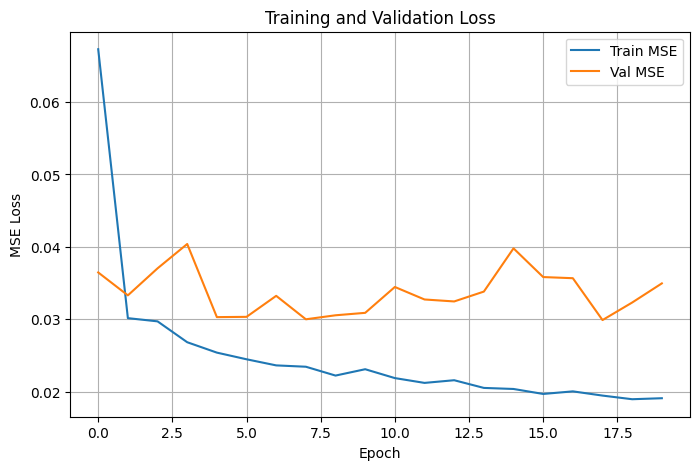

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses, label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## Roadmap

0. Importing libraries, definition of functions and classes
* Importing libraries

* Function definition

* Class definition

1. Data Preparation

  * Loading the data
  * Create dataset
  * Save dataset  
  * Splitting data into train, val, test  
  * Scaling the data  
  * Splitting into X,y  
  * Creating sequences  
  * Saving sequences  
  * Converting to tensors  
  * Creating datasets  
  * Creating dataloaders
  
   2. Model
  * Creating an instance of the model class LSTMForecaster
  
  3. Training
  * Optimizer
  * Loss function
  * Training loop pro batches
  * Validation loop pro batches
      
  4. Validation
  * Calculate Metrics --> RMSE / MAE / R2


## The full script

In [ ]:
# --------------------------------------------
# ----------- Importing libraries ------------
# --------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split



# --------------------------------------------
# ----------- Function definition ------------
# --------------------------------------------

def train_val_test_split_by_date(data, train_end_date, val_end_date):
    """
    Split time series by specific dates.

    Parameters:
    -----------
    data : pandas DataFrame with DatetimeIndex
    train_end_date : str or datetime
        Last date for training set
    val_end_date : str or datetime
        Last date for validation set

    Returns:
    --------
    train, val, test : pandas DataFrame
    """
    train = data[:train_end_date]
    val = data[train_end_date:val_end_date]
    test = data[val_end_date:]

    return train, val, test


def scale(train, val, test, method='minmax'):
    """
    Scale data using only training set statistics.

    Parameters:
    -----------
    train, val, test : pandas DataFrame
    method : str
        'minmax' or 'standard'

    Returns:
    --------
    train_scaled, val_scaled, test_scaled, scaler
    """
    # Choose scaler
    if method == 'minmax':
        scaler = MinMaxScaler()
    elif method == 'standard':
        scaler = StandardScaler()
    else:
        raise ValueError("method must be 'minmax' or 'standard'")

    # Fit on train, transform all (keeping DataFrame structure)
    train_scaled = pd.DataFrame(
        scaler.fit_transform(train),
        index=train.index,
        columns=train.columns
    )

    val_scaled = pd.DataFrame(
        scaler.transform(val),
        index=val.index,
        columns=val.columns
    )

    test_scaled = pd.DataFrame(
        scaler.transform(test),
        index=test.index,
        columns=test.columns
    )

    return train_scaled, val_scaled, test_scaled, scaler


def inverse_scale(data, scaler):
    """
    Inverse transform scaled data back to original scale.

    Parameters:
    -----------
    data : numpy array or pandas DataFrame
        Scaled data
    scaler : sklearn scaler object
        Fitted scaler from scale_train_only()

    Returns:
    --------
    numpy array or pandas DataFrame in original scale
    """
    return scaler.inverse_transform(data)


def split_features_target(data, target_column):
    """
    Split DataFrame into features (X) and target (y).

    Parameters:
    -----------
    data : pandas DataFrame
        The dataset to split
    target_column : str or list of str
        Name(s) of the target column(s)

    Returns:
    --------
    X : pandas DataFrame
        Features (all columns except target)
    y : pandas DataFrame or Series
        Target column(s)
    """
    if isinstance(target_column, str):
        # Single target column
        y = data[[target_column]]  # Keep as DataFrame
        X = data.drop(columns=[target_column])
    else:
        # Multiple target columns
        y = data[target_column]
        X = data.drop(columns=target_column)

    return X, y


def create_sequences(X_data, y_data, lookback, horizon):
    """
    Create sequences for multivariate multi-step time series forecasting.

    Parameters:
    -----------
    X_data : numpy array or pandas DataFrame
        Feature data (all input variables)
    y_data : numpy array or pandas DataFrame
        Target data (variable(s) to predict)
    lookback : int
        Number of past time steps to use as input (window size)
    horizon : int
        Number of future time steps to predict

    Returns:
    --------
    X : numpy array, shape (samples, lookback, n_features)
        Input sequences (past features)
    y : numpy array, shape (samples, horizon, n_targets)
        Target sequences (future target values)
    """
    X, y = [], []

    # Convert to numpy if DataFrame
    if hasattr(X_data, 'values'):
        X_data = X_data.values
    if hasattr(y_data, 'values'):
        y_data = y_data.values

    for i in range(len(X_data) - lookback - horizon + 1):
        # Input: past 'lookback' time steps of features
        X.append(X_data[i:i + lookback])

        # Output: next 'horizon' time steps of target
        y.append(y_data[i + lookback:i + lookback + horizon])

    X = np.array(X)
    y = np.array(y)

    return X, y


def save_sequences(X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, save_dir):
    # Save sequences
    np.save(os.path.join(save_dir, "X_train_seq.npy"), X_train_seq)
    np.save(os.path.join(save_dir, "y_train_seq.npy"), y_train_seq)
    np.save(os.path.join(save_dir, "X_val_seq.npy"), X_val_seq)
    np.save(os.path.join(save_dir, "y_val_seq.npy"), y_val_seq)
    np.save(os.path.join(save_dir, "X_test_seq.npy"), X_test_seq)
    np.save(os.path.join(save_dir, "y_test_seq.npy"), y_test_seq)

    # Save scalers
    joblib.dump(scaler_train, os.path.join(save_dir, "scaler_train.pkl"))


# --------------------------------------------
# ----------- Class definition ---------------
# --------------------------------------------

class LSTMForecaster(nn.Module):
    def __init__(
        self,
        n_features,
        hidden_size,
        num_layers,
        horizon,
        n_targets,
        dropout=0.0
    ):
        super().__init__()

        self.horizon = horizon
        self.n_targets = n_targets

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Maps last hidden state -> horizon * targets
        self.fc = nn.Linear(hidden_size, horizon * n_targets)

    def forward(self, x):
        """
        x: (B, lookback, n_features)
        return: (B, horizon, n_targets)
        """
        _, (h_n, _) = self.lstm(x)

        # Take last layer hidden state
        h_last = h_n[-1]          # (B, hidden_size)

        out = self.fc(h_last)    # (B, horizon * n_targets)
        out = out.view(-1, self.horizon, self.n_targets)

        return out


if __name__ == "__main__":

  # --------------------------------------------
  # ----------- 1 - Data Preparation -----------
  # --------------------------------------------

  # Loading the data
  general_path = '/content/drive/My Drive/RS - IEEE - ESA/notebooks'  # ajusta la ruta
  list_of_files = os.listdir(general_path)
  list_of_parquet = [f for f in list_of_files if '.parquet' in f]
  print(list_of_parquet)

  dataframes = {}

  for file in list_of_parquet:
    file_path = os.path.join(general_path, file)
    print(file)

    # if "precipitation" in file:
    #   continue

    df = pd.read_parquet(file_path)
    df_resampled = df.copy()

    print(df.info())

    if 'discharge' in str(file):
      df_resampled = df.resample('30min').mean()
    else:
      df_resampled = df.resample('30min').sum()

    file_prefix = file.replace('.parquet', '')
    df_resampled.columns = [f"{file_prefix}" for col in df_resampled.columns]

    # Store in dictionary
    dataframes[file] = df_resampled

  # Merge using outer join to keep all timestamps
  merged_df = pd.concat(dataframes.values(), axis=1, join='outer')

  # Sort by index
  merged_df = merged_df.sort_index()

  # Save dataset
  dataset_name = "dataset.parquet"
  general_path_parquet = '/content/drive/My Drive/RS - IEEE - ESA/notebooks'  # ajusta la ruta
  os.makedirs(os.path.join(general_path_parquet, 'datasets'), exist_ok=True)
  dataset_path = os.path.join(general_path_parquet, 'datasets', dataset_name)
  merged_df.to_parquet(dataset_path)

  data = pd.read_parquet(dataset_path)

  # Splitting data into train, val, test
  train, val, test = train_val_test_split_by_date(
    data,
    train_end_date='2021-01-01',
    val_end_date='2021-07-01')

  # Scaling the data
  train_scaled, val_scaled, test_scaled, scaler_train = scale(train, val, test, method='standard')

  # Splitting into X,y
  target_column='discharge_klu'
  X_train, y_train = split_features_target(train_scaled, target_column)
  X_val, y_val = split_features_target(val_scaled, target_column)
  X_test, y_test = split_features_target(test_scaled, target_column)

  # Creating sequences
  lookback = 12 # 12 Timestamps --> Each timestamp 15 min --> 3 hours into the past
  horizon = 8 # 8 Timestamps --> 2 hours into the future
  X_train_seq, y_train_seq = create_sequences(X_train, y_train, lookback, horizon)
  X_val_seq, y_val_seq = create_sequences(X_val, y_val, lookback, horizon)
  X_test_seq, y_test_seq = create_sequences(X_test, y_test, lookback, horizon)

  # Saving sequences
  save_dir = os.path.join(general_path_parquet, 'sequences')
  os.makedirs(save_dir, exist_ok=True)
  save_sequences(X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, save_dir)

  # Converting to tensors
  X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
  y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)
  X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32)
  y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32)
  X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
  y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

  # Creating datasets
  dataset_train = TensorDataset(X_train_tensor, y_train_tensor)
  dataset_val = TensorDataset(X_val_tensor, y_val_tensor)
  dataset_test = TensorDataset(X_test_tensor, y_test_tensor)

  # Creating dataloaders
  train_loader = DataLoader(dataset_train, batch_size=32, shuffle=True)
  val_loader = DataLoader(dataset_val, batch_size=32, shuffle=False)
  test_loader = DataLoader(dataset_test, batch_size=32, shuffle=False)

  # --------------------------------------------
  # ----------- 2 - Model ----------------------
  # --------------------------------------------

  # Creating an instance of the model class LSTMForecaster
  model = LSTMForecaster(
    n_features=3,
    hidden_size=128,
    num_layers=2,
    horizon=8,
    n_targets=1,
    dropout=0.2
  )
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)

  # --------------------------------------------
  # ----------- 3 - Training ----------------------
  # --------------------------------------------

  import torch.optim as optim
  import torch.nn.functional as F
  import torch.nn as nn

  optimizer = optim.Adam(model.parameters(), lr=1e-3)
  criterion = nn.MSELoss()
  num_epochs = 20

  # Lists for plotting
  train_losses, val_losses = [], []

  for epoch in range(num_epochs):

      # Training
      model.train()
      train_loss = 0.0
      for X_batch, y_batch in train_loader:
          X_batch = X_batch.to(device)
          y_batch = y_batch.to(device)
          optimizer.zero_grad()
          preds = model(X_batch)
          loss = criterion(preds, y_batch)
          loss.backward()
          optimizer.step()
          train_loss += loss.item()
      train_loss /= len(train_loader)
      train_losses.append(train_loss)

      # Validation
      model.eval()
      val_loss = 0.0
      val_preds_all = []
      val_targets_all = []
      with torch.no_grad():
          for X_batch, y_batch in val_loader:
              preds = model(X_batch)
              loss = F.mse_loss(preds, y_batch)
              val_loss += loss.item()
              val_preds_all.append(preds.numpy())
              val_targets_all.append(y_batch.numpy())
      val_loss /= len(val_loader)
      val_losses.append(val_loss)

      print(f"Epoch {epoch+1}/{num_epochs} - Train MSE: {train_loss:.4f} - Val MSE: {val_loss:.4f}")

  # --------------------------------------------
  # ----------- 4 - Validation -----------------
  # --------------------------------------------

  val_preds = np.concatenate(val_preds_all, axis=0).reshape(-1, 1)
  val_targets = np.concatenate(val_targets_all, axis=0).reshape(-1, 1)

  rmse = np.sqrt(mean_squared_error(val_targets, val_preds))
  mae = mean_absolute_error(val_targets, val_preds)
  r2 = r2_score(val_targets, val_preds)

  print(f"Validation RMSE: {rmse:.4f}")
  print(f"Validation MAE: {mae:.4f}")
  print(f"Validation R2: {r2:.4f}")


Análisis

Qué se puede mejorar?
* muchas líneas de código -> agrupar funciones y clase en módulos
* crear scaler para X_train, y_train